# Chapter 1: From Text to Searchable Vectors

This demo walks through the **feature extraction pipeline** that transforms raw text
into the vector representations used by every classical retrieval model.

**Learning goals:**
- Trace each pipeline stage: tokenize, normalize, stem, build vocabulary, compute vectors
- Observe what information is preserved (and lost) at each transformation
- Connect Zipf's law to term discrimination and IDF weighting
- Build set-of-words, bag-of-words, and TF-IDF representations for a small collection

**Prerequisites:** Chapter 1.2 (From Text to Searchable Vectors) in the textbook.

In [1]:
from shared.collections import load_collection, available_collections
from shared.display import print_table, display_md
from shared.text import tokenize, remove_stopwords, stopwords_for
import ipywidgets as widgets
import re
import math
from collections import Counter

## Select a Collection

In [2]:
_names = [c["name"] for c in available_collections()]

_dropdown = widgets.Dropdown(
    options=_names,
    value="mini",
    description="Collection:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="450px"),
)
display(_dropdown)

Dropdown(description='Collection:', index=12, layout=Layout(width='450px'), options=('books', 'books-alice', '…

In [3]:
collection = load_collection(_dropdown.value)

display_md(
    f"**{collection.name}** — {collection.description}\n\n"
    f"- Documents: **{len(collection)}**\n"
    f"- Language: {collection.language}"
)

**mini** — 12 hand-crafted documents for formula tracing (Ch. 1 running example)

- Documents: **12**
- Language: en

## The Collection

In [4]:
# Show the documents (first 15 for larger collections)
rows = [[doc["id"], doc["text"][:80] + ("..." if len(doc["text"]) > 80 else "")]
        for doc in list(collection)[:15]]

print_table(rows, headers=["ID", "Document"])

if len(collection) > 15:
    display_md(f"*...and {len(collection) - 15} more documents.*")

| ID   | Document                                                                            |
|:-----|:------------------------------------------------------------------------------------|
| b1   | The Cat and Dog in the Forest. A cat and a dog begin a woodland adventure.          |
| b2   | Cats of the Woodland. Wild cats begin an adventure beneath ancient trees.           |
| b3   | The Forest Hound. A loyal dog follows a woodland trail through ancient trees.       |
| b4   | Feline Detective. A clever cat solves mysteries with a canine companion.            |
| b5   | Random Forest for Pet Detection. A random forest model classifies cats and dogs ... |
| b6   | Forests of Search Trees. Algorithms explore a forest of binary trees and graph p... |
| b7   | Dog Dog Dog! A dog chases a ball, finds a bone, and wakes the neighbors.            |
| b8   | Forest Forest Forest! A forest guide names trees, flowers, rivers, birds, and hi... |
| b9   | Cat Dog Forest.                                                                     |
| b10  | Cat Dog Forest. A cat meets a dog in a forest beside rivers, mountains, castles,... |
| b11  | Woodland Companions. A kitten and a puppy share a moonlit adventure among old tr... |
| b12  | The Pet Bakery. A cat, a dog, and a baker make cakes, bread, biscuits, pies, and... |

Each document is still raw text: mixed case, punctuation, articles, and inflected forms.
A retrieval model cannot compare these directly — it needs structured representations.
The pipeline below produces them step by step.

---
## Step 1: Tokenization

Tokenization splits the raw character stream into discrete **tokens** — typically words.
Decisions here (how to handle punctuation, case, hyphens) propagate through the entire pipeline.

Our tokenizer lowercases and splits on non-word characters:

In [5]:
# Apply to the first document
doc = collection.documents()[0]
tokens = tokenize(doc["text"])

display_md(
    f"**Document `{doc['id']}`**\n\n"
    f"Raw text: {doc['text'][:120]}{'...' if len(doc['text']) > 120 else ''}\n\n"
    f"**Tokens ({len(tokens)}):** {tokens[:20]}{'...' if len(tokens) > 20 else ''}"
)

**Document `b1`**

Raw text: The Cat and Dog in the Forest. A cat and a dog begin a woodland adventure.

**Tokens (16):** ['the', 'cat', 'and', 'dog', 'in', 'the', 'forest', 'a', 'cat', 'and', 'a', 'dog', 'begin', 'a', 'woodland', 'adventure']

Notice what happens:
- "The" becomes "the" (case folding)
- Punctuation is removed
- Multi-word meaning ("Random Forest") is lost — each word becomes an independent token

In [6]:
# Tokenize the entire collection
corpus_raw = {doc["id"]: tokenize(doc["text"]) for doc in collection}

print_table(
    [[doc_id, len(tokens), " ".join(tokens[:8]) + ("..." if len(tokens) > 8 else "")]
     for doc_id, tokens in list(corpus_raw.items())[:15]],
    headers=["ID", "# Tokens", "First tokens"]
)

| ID   |   # Tokens | First tokens                                           |
|:-----|-----------:|:-------------------------------------------------------|
| b1   |         16 | the cat and dog in the forest a...                     |
| b2   |         12 | cats of the woodland wild cats begin an...             |
| b3   |         13 | the forest hound a loyal dog follows a...              |
| b4   |         11 | feline detective a clever cat solves mysteries with... |
| b5   |         15 | random forest for pet detection a random forest...     |
| b6   |         14 | forests of search trees algorithms explore a forest... |
| b7   |         15 | dog dog dog a dog chases a ball...                     |
| b8   |         14 | forest forest forest a forest guide names trees...     |
| b9   |          3 | cat dog forest                                         |
| b10  |         19 | cat dog forest a cat meets a dog...                    |
| b11  |         14 | woodland companions a kitten and a puppy share...      |
| b12  |         17 | the pet bakery a cat a dog and...                      |

---
## Step 2: Stop Word Removal

Many tokens are grammatically necessary but carry no topical information.
"The", "a", "and", "in" appear in nearly every document — they cannot help
distinguish a relevant document from an irrelevant one.

In [7]:
# Show stopwords for the collection's language
lang = collection.language or "all"
sw = stopwords_for(lang) if lang not in ("mixed", "all") else stopwords_for("en")

display_md(
    f"**Stopwords for `{lang}`:** {len(sw)} words\n\n"
    f"Sample: {', '.join(sorted(list(sw))[:20])}, ..."
)

**Stopwords for `en`:** 198 words

Sample: a, about, above, after, again, against, ain, all, am, an, and, any, are, aren, aren't, as, at, be, because, been, ...

In [8]:
# Before and after for the first document
doc_id = collection.ids()[0]
before = corpus_raw[doc_id]
after = remove_stopwords(before, collection.language or "all")

display_md(
    f"**Document `{doc_id}`**\n\n"
    f"Before ({len(before)} tokens): {before[:15]}...\n\n"
    f"After ({len(after)} tokens): {after[:15]}...\n\n"
    f"Removed: {[t for t in before if t not in set(after)][:15]}..."
)

**Document `b1`**

Before (16 tokens): ['the', 'cat', 'and', 'dog', 'in', 'the', 'forest', 'a', 'cat', 'and', 'a', 'dog', 'begin', 'a', 'woodland']...

After (8 tokens): ['cat', 'dog', 'forest', 'cat', 'dog', 'begin', 'woodland', 'adventure']...

Removed: ['the', 'and', 'in', 'the', 'a', 'and', 'a', 'a']...

In [9]:
# Apply to entire collection
corpus = {doc_id: remove_stopwords(tokens, collection.language or "all")
          for doc_id, tokens in corpus_raw.items()}

# How much did we remove?
print_table(
    [[doc_id, len(corpus_raw[doc_id]), len(corpus[doc_id]),
      f"{(1 - len(corpus[doc_id])/max(1, len(corpus_raw[doc_id])))*100:.0f}%"]
     for doc_id in list(corpus.keys())[:15]],
    headers=["ID", "Before", "After", "Removed %"]
)

| ID   |   Before |   After | Removed %   |
|:-----|---------:|--------:|:------------|
| b1   |       16 |       8 | 50%         |
| b2   |       12 |       9 | 25%         |
| b3   |       13 |       9 | 31%         |
| b4   |       11 |       8 | 27%         |
| b5   |       15 |      11 | 27%         |
| b6   |       14 |      10 | 29%         |
| b7   |       15 |      10 | 33%         |
| b8   |       14 |      12 | 14%         |
| b9   |        3 |       3 | 0%          |
| b10  |       19 |      14 | 26%         |
| b11  |       14 |      10 | 29%         |
| b12  |       17 |      11 | 35%         |

**Observation:** Stop words account for roughly 30-50% of all tokens, yet they carry
almost no information about document content. Removing them shrinks the vocabulary
and focuses the representation on content-bearing terms.

---
## Step 3: Stemming (Optional)

Stemming reduces inflected forms to a common pseudo-stem so that related words
map to the same vocabulary entry. The Porter stemmer strips suffixes using
a sequence of rules:

| Input | Porter stem | Effect |
|-------|-------------|--------|
| "cats" | "cat" | Plural |
| "computing", "computed" | "comput" | Inflection |
| "adventure", "adventures" | "adventur" | Plural |
| "retrieval", "retrieving" | "retriev" | Verb form |

The stem is not always a real word — it only needs to be consistent.

In [10]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

# Demonstrate on selected words from our collection
sample_words = set()
for tokens in list(corpus.values())[:10]:
    sample_words.update(tokens[:10])
examples = sorted(list(sample_words))[:12]

print_table(
    [[word, stemmer.stem(word)] for word in examples],
    headers=["Input", "Porter Stem"]
)

| Input      | Porter Stem   |
|:-----------|:--------------|
| adventure  | adventur      |
| algorithms | algorithm     |
| ancient    | ancient       |
| ball       | ball          |
| begin      | begin         |
| beneath    | beneath       |
| beside     | besid         |
| binary     | binari        |
| birds      | bird          |
| bone       | bone          |
| canine     | canin         |
| cat        | cat           |

For this demo, we deliberately **skip stemming** to keep terms readable and to
expose lexical mismatch problems (e.g., "cat" vs "cats" remain separate).

---
## Step 4: Vocabulary and Document Frequency

The **vocabulary** is the set of all distinct terms that appear in any document.
Each term becomes one dimension in our vector space.

The **document frequency** df(t) counts how many documents contain term t.
It tells us how common (and therefore how undiscriminating) a term is.

In [11]:
def document_frequencies(corpus: dict[str, list[str]]) -> dict[str, int]:
    """Count how many documents contain each term."""
    df = Counter()
    for tokens in corpus.values():
        df.update(set(tokens))
    return dict(df)

df = document_frequencies(corpus)
vocab = sorted(df.keys())
N = len(corpus)

display_md(f"**Vocabulary size:** {len(vocab)} terms | **Documents:** {N}")

**Vocabulary size:** 71 terms | **Documents:** 12

In [12]:
# Sort terms by document frequency (most common first)
df_sorted = sorted(df.items(), key=lambda x: -x[1])

display_md("**Most common terms** (appear in many documents):")
print_table(
    [[term, freq, f"{freq/N*100:.0f}%"] for term, freq in df_sorted[:15]],
    headers=["Term", "df", "% of docs"]
)

**Most common terms** (appear in many documents):

| Term      |   df | % of docs   |
|:----------|-----:|:------------|
| forest    |    7 | 58%         |
| dog       |    6 | 50%         |
| cat       |    5 | 42%         |
| trees     |    5 | 42%         |
| woodland  |    4 | 33%         |
| adventure |    3 | 25%         |
| begin     |    2 | 17%         |
| ancient   |    2 | 17%         |
| cats      |    2 | 17%         |
| pet       |    2 | 17%         |
| rivers    |    2 | 17%         |
| beneath   |    1 | 8%          |
| wild      |    1 | 8%          |
| loyal     |    1 | 8%          |
| trail     |    1 | 8%          |

In [13]:
# Rare terms
rare_terms = [t for t, f in df_sorted if f == 1]
display_md(
    f"**Rare terms** (df=1): {len(rare_terms)} / {len(vocab)} "
    f"({len(rare_terms)*100//len(vocab)}% of vocabulary)\n\n"
    f"Examples: {', '.join(rare_terms[:15])}"
)

**Rare terms** (df=1): 60 / 71 (84% of vocabulary)

Examples: beneath, wild, loyal, trail, hound, follows, clever, mysteries, detective, companion, feline, canine, solves, classifies, random

---
## Step 5: Zipf's Law and Term Discrimination

The distribution of term frequencies in natural language follows a power law.
A few terms dominate, while most are rare. Let's visualize this:

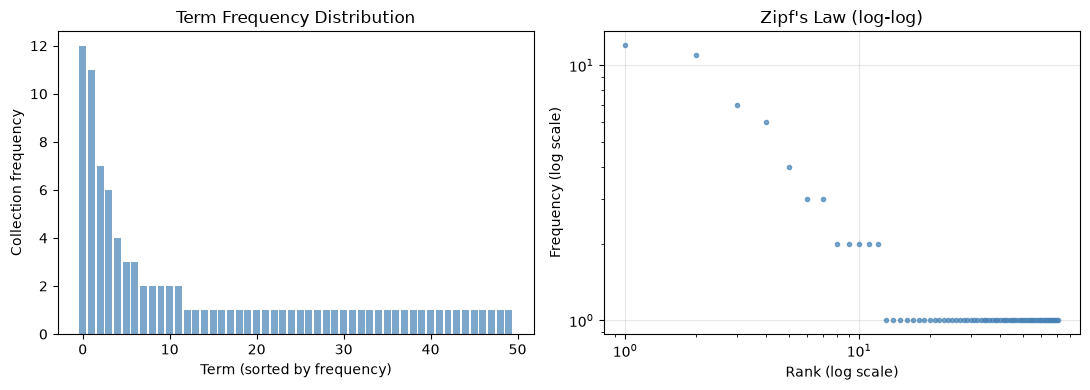

In [14]:
import matplotlib.pyplot as plt

# Collection frequency: total occurrences of each term across all documents
cf = Counter()
for tokens in corpus.values():
    cf.update(tokens)

# Sort by frequency, compute rank
cf_sorted = cf.most_common()
ranks = range(1, len(cf_sorted) + 1)
freqs = [f for _, f in cf_sorted]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# Linear scale
ax1.bar(range(len(freqs[:50])), freqs[:50], color="steelblue", alpha=0.7)
ax1.set_xlabel("Term (sorted by frequency)")
ax1.set_ylabel("Collection frequency")
ax1.set_title("Term Frequency Distribution")

# Log-log scale (Zipf's law appears as straight line)
ax2.loglog(ranks, freqs, "o", markersize=3, color="steelblue", alpha=0.7)
ax2.set_xlabel("Rank (log scale)")
ax2.set_ylabel("Frequency (log scale)")
ax2.set_title("Zipf's Law (log-log)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Key insight:** Terms fall into three zones:
1. **Very common** (top of Zipf curve): appear everywhere, cannot discriminate
2. **Very rare** (tail): highly specific but unlikely to occur in queries
3. **Middle zone**: the most useful terms for distinguishing relevant from non-relevant

---
## Step 6: IDF — Quantifying Discrimination Power

**Inverse Document Frequency** assigns higher weights to terms that appear in fewer documents.
This is the key mechanism that makes common terms less important than rare ones.

$$\text{idf}(t) = \log\frac{N}{\text{df}(t)}$$

In [15]:
def idf(term: str, df: dict[str, int], n: int) -> float:
    """Classic IDF: log(N / df)."""
    return math.log(n / df.get(term, 1))

In [16]:
# Compute IDF for all terms and display ranked
idf_values = {term: idf(term, df, N) for term in vocab}
idf_sorted = sorted(idf_values.items(), key=lambda x: -x[1])

display_md("**IDF values** (higher = more discriminating):")
print_table(
    [[term, df[term], f"{idf_val:.3f}"]
     for term, idf_val in idf_sorted[:15]],
    headers=["Term", "df", "IDF"]
)

**IDF values** (higher = more discriminating):

| Term       |   df |   IDF |
|:-----------|-----:|------:|
| algorithms |    1 | 2.485 |
| among      |    1 | 2.485 |
| baker      |    1 | 2.485 |
| bakery     |    1 | 2.485 |
| ball       |    1 | 2.485 |
| beneath    |    1 | 2.485 |
| beside     |    1 | 2.485 |
| binary     |    1 | 2.485 |
| birds      |    1 | 2.485 |
| biscuits   |    1 | 2.485 |
| bone       |    1 | 2.485 |
| bread      |    1 | 2.485 |
| bridges    |    1 | 2.485 |
| cakes      |    1 | 2.485 |
| canine     |    1 | 2.485 |

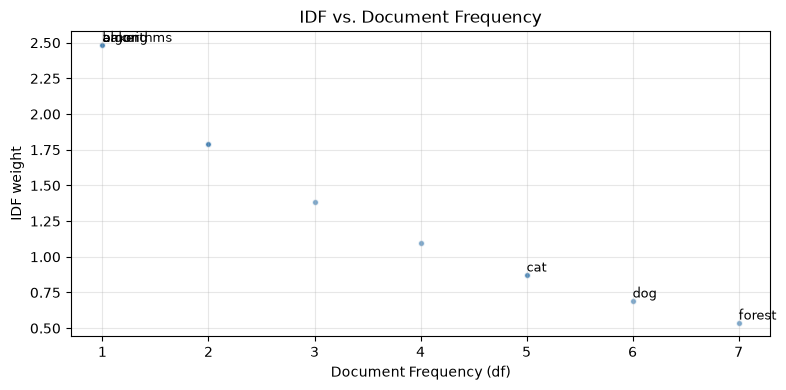

In [17]:
# Visualize: IDF vs document frequency
fig, ax = plt.subplots(figsize=(8, 4))

terms_plot = [t for t, _ in df_sorted]
idf_plot = [idf_values[t] for t in terms_plot]
df_plot = [df[t] for t in terms_plot]

ax.scatter(df_plot, idf_plot, c="steelblue", alpha=0.7, edgecolors="white", s=20)

# Annotate a few interesting terms (top IDF and top DF)
for term in list(dict(idf_sorted[:3]).keys()) + list(dict(df_sorted[:3]).keys()):
    if term in df and term in idf_values:
        ax.annotate(term, (df[term], idf_values[term]),
                    fontsize=9, ha="left", va="bottom")

ax.set_xlabel("Document Frequency (df)")
ax.set_ylabel("IDF weight")
ax.set_title("IDF vs. Document Frequency")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Step 7: Document Representations

We now have everything needed to represent documents as vectors. Three options,
from simplest to most informative:

### Set-of-Words (Binary)

Each dimension is 1 (term present) or 0 (term absent). Frequency is ignored.

In [18]:
def set_of_words_vector(tokens: list[str], vocab: list[str]) -> list[int]:
    """Binary vector: 1 if term present, 0 otherwise."""
    token_set = set(tokens)
    return [1 if t in token_set else 0 for t in vocab]

### Bag-of-Words (Term Frequency)

Each dimension records how many times the term appears. Repetition matters.

In [19]:
def bag_of_words_vector(tokens: list[str], vocab: list[str]) -> list[int]:
    """Term frequency vector."""
    tf = Counter(tokens)
    return [tf.get(t, 0) for t in vocab]

### TF-IDF (Weighted)

Multiply term frequency by IDF. Common terms get diminished, rare terms get amplified.

In [20]:
def tfidf_vector(tokens: list[str], df: dict[str, int], n: int, vocab: list[str]) -> list[float]:
    """TF-IDF vector: tf * log(N/df) for each vocabulary term."""
    tf = Counter(tokens)
    return [tf.get(t, 0) * math.log(n / df.get(t, 1)) for t in vocab]

In [21]:
# Compare representations for two documents
ids = collection.ids()
id_a, id_b = ids[0], ids[min(1, len(ids)-1)]

vec_sow_a = set_of_words_vector(corpus[id_a], vocab)
vec_sow_b = set_of_words_vector(corpus[id_b], vocab)
vec_bow_a = bag_of_words_vector(corpus[id_a], vocab)
vec_bow_b = bag_of_words_vector(corpus[id_b], vocab)
vec_tfidf_a = tfidf_vector(corpus[id_a], df, N, vocab)

# Show non-zero terms for doc A
display_md(f"**Document `{id_a}` — non-zero entries:**")
print_table(
    [[vocab[i], vec_sow_a[i], vec_bow_a[i], f"{vec_tfidf_a[i]:.3f}"]
     for i in range(len(vocab)) if vec_bow_a[i] > 0][:20],
    headers=["Term", "Set-of-Words", "Bag-of-Words", "TF-IDF"]
)

**Document `b1` — non-zero entries:**

| Term      |   Set-of-Words |   Bag-of-Words |   TF-IDF |
|:----------|---------------:|---------------:|---------:|
| adventure |              1 |              1 |    1.386 |
| begin     |              1 |              1 |    1.792 |
| cat       |              1 |              2 |    1.751 |
| dog       |              1 |              2 |    1.386 |
| forest    |              1 |              1 |    0.539 |
| woodland  |              1 |              1 |    1.099 |

**Key observation:** TF-IDF balances how often a term appears in *this* document against
how common it is across *all* documents.

---
## The Complete TF-IDF Matrix

Stacking all document vectors produces the **term-document matrix**.
This is the fundamental data structure for vector-space retrieval.

In [22]:
import numpy as np

# Build the full TF-IDF matrix
doc_ids = list(corpus.keys())
matrix = np.array([tfidf_vector(corpus[d], df, N, vocab) for d in doc_ids])

display_md(
    f"**Matrix shape:** {matrix.shape} ({len(doc_ids)} documents x {len(vocab)} terms)\n\n"
    f"- Non-zero entries: {np.count_nonzero(matrix)} / {matrix.size} "
    f"({np.count_nonzero(matrix)/matrix.size*100:.1f}%)\n"
    f"- Sparsity: {(1 - np.count_nonzero(matrix)/matrix.size)*100:.1f}%"
)

**Matrix shape:** (12, 71) (12 documents x 71 terms)

- Non-zero entries: 100 / 852 (11.7%)
- Sparsity: 88.3%

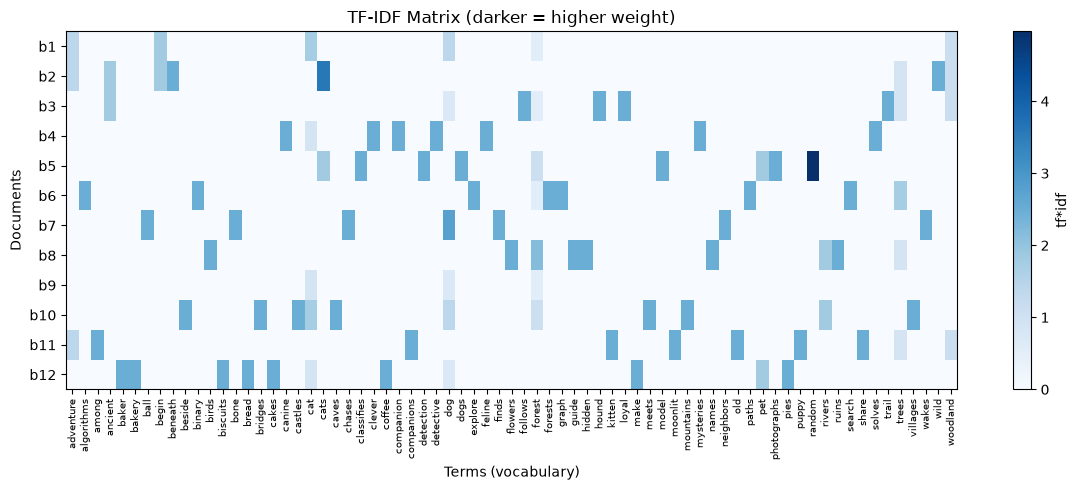

In [23]:
# Visualize as heatmap (only practical for small collections)
if len(doc_ids) <= 30 and len(vocab) <= 100:
    fig, ax = plt.subplots(figsize=(12, 5))
    im = ax.imshow(matrix, aspect="auto", cmap="Blues")
    ax.set_yticks(range(len(doc_ids)))
    ax.set_yticklabels(doc_ids)
    ax.set_xticks(range(len(vocab)))
    ax.set_xticklabels(vocab, rotation=90, fontsize=7)
    ax.set_xlabel("Terms (vocabulary)")
    ax.set_ylabel("Documents")
    ax.set_title("TF-IDF Matrix (darker = higher weight)")
    plt.colorbar(im, ax=ax, label="tf*idf")
    plt.tight_layout()
    plt.show()
else:
    display_md(
        f"*Matrix too large to visualize as heatmap "
        f"({len(doc_ids)} x {len(vocab)}). "
        f"Try selecting the 'mini' collection to see the full heatmap.*"
    )

**Observe the sparsity:** Most cells are zero. Each document uses only a small fraction
of the vocabulary. This is why inverted indexes work — we only need to store and
compare the non-zero entries.

---
## Lessons Learned

| Stage | What it does | What is lost |
|-------|-------------|--------------|
| Tokenization | Splits text into words, lowercases | Word order, punctuation meaning, case |
| Stop word removal | Removes frequent non-content words | Function words, potential entity names |
| Stemming | Merges inflected forms | Distinction between forms (if applied) |
| Vocabulary + df | Defines the vector space | Nothing — just organization |
| IDF weighting | Weights terms by discrimination power | Nothing — adds information |
| TF-IDF vector | Final document representation | Order, proximity, semantics |

**Key takeaway:** The feature extraction pipeline trades richness for comparability.
We lose word order, semantics, and exact form — but we gain a structured representation
that allows efficient, principled comparison between queries and documents.

**Next:** In the retrieval models demo (ch01-02), we use these TF-IDF vectors to
rank documents with Boolean, VSM, and BM25 — and see how each model's assumptions
produce different rankings for the same query.

---
## Try It Yourself

Go back to the dropdown and select a different collection, then re-run the notebook.

Things to observe:
- How does the Zipf plot change with a larger collection?
- Which collection has the highest sparsity?
- What happens to IDF values when N grows?

In [24]:
# Experiment: What happens if you add stemming?
stemmed_corpus = {
    doc_id: [stemmer.stem(t) for t in tokens]
    for doc_id, tokens in corpus.items()
}

df_stemmed = document_frequencies(stemmed_corpus)
vocab_stemmed = sorted(df_stemmed.keys())

display_md(
    f"**Effect of stemming:**\n\n"
    f"| | Before | After |\n"
    f"|---|---|---|\n"
    f"| Vocabulary | {len(vocab)} terms | {len(vocab_stemmed)} terms |\n"
    f"| Reduction | — | {len(vocab) - len(vocab_stemmed)} terms merged |"
)

**Effect of stemming:**

| | Before | After |
|---|---|---|
| Vocabulary | 71 terms | 66 terms |
| Reduction | — | 5 terms merged |